# Estudio Correlacional

Completar csv con variables faltantes

In [ ]:
import os
import pandas as pd

carpetas = ["tramos_Drenaje", "tramosRiego"]
hs_range = range(10, 61, 10)
ruta_lc = "csv/LC_horario.csv"

if not os.path.exists(ruta_lc):
    raise FileNotFoundError("No se encuentra LC_horario.csv en el directorio actual")

df_lc = pd.read_csv(ruta_lc)

cols_lc = [
    col for col in df_lc.columns
    if col.startswith("TS30") 
    or col.startswith("HA") 
    or col.startswith("TA")
]

if "instante" not in cols_lc:
    cols_lc.insert(0, "instante")

df_lc_sel = df_lc[cols_lc]

for carpeta in carpetas:
    
    for hs in hs_range:
        
        nombre = f"HS{hs}_tramos.csv"
        ruta_hs = os.path.join(carpeta, nombre)
        
        if not os.path.exists(ruta_hs):
            print(f"No existe {ruta_hs}")
            continue
        
        df_hs = pd.read_csv(ruta_hs)
        
        df_final = pd.merge(
            df_hs,
            df_lc_sel,
            on="instante",
            how="left"
        )
        
        salida = os.path.join(carpeta, f"HS{hs}_tramos_completo.csv")
        df_final.to_csv(salida, index=False)
        
        print(f"Generado: {salida}")

Generado: tramos_Drenaje\HS10_tramos_completo.csv
Generado: tramos_Drenaje\HS20_tramos_completo.csv
Generado: tramos_Drenaje\HS30_tramos_completo.csv
Generado: tramos_Drenaje\HS40_tramos_completo.csv
Generado: tramos_Drenaje\HS50_tramos_completo.csv
Generado: tramos_Drenaje\HS60_tramos_completo.csv
Generado: tramosRiego\HS10_tramos_completo.csv
Generado: tramosRiego\HS20_tramos_completo.csv
Generado: tramosRiego\HS30_tramos_completo.csv
Generado: tramosRiego\HS40_tramos_completo.csv
Generado: tramosRiego\HS50_tramos_completo.csv
Generado: tramosRiego\HS60_tramos_completo.csv


Union tramos

In [ ]:
import os
import pandas as pd

carpetas = ["tramos_Drenaje", "tramosRiego"]
hs_range = range(10, 61, 10)

for carpeta in carpetas:
    
    dfs = []
    
    for hs in hs_range:
        nombre = f"HS{hs}_tramos_completo.csv"
        ruta = os.path.join(carpeta, nombre)
        
        if not os.path.exists(ruta):
            print(f"No existe {ruta}")
            continue
        
        df = pd.read_csv(ruta)
        
        df["instante"] = pd.to_datetime(df["instante"], errors="coerce")
        
        dfs.append(df)
    
    if not dfs:
        print(f"No hay archivos en {carpeta}")
        continue
    
    # Unir todos
    df_union = pd.concat(dfs, ignore_index=True)
    
    # Eliminar instantes duplicados
    df_union = df_union.drop_duplicates(subset="instante")
    df_union = df_union.sort_values("instante")
   
    salida = os.path.join(carpeta, "HS_tramos_unicos.csv")
    df_union.to_csv(salida, index=False)
    
    print(f"Generado archivo limpio en {salida}")

Generado archivo limpio en tramosDrenaje\HS_tramos_unicos.csv
Generado archivo limpio en tramosRiego\HS_tramos_unicos.csv


Interseccion tramos

In [ ]:
import os
import pandas as pd

carpetas = ["tramosDrenaje", "tramosRiego"]
hs_range = range(10, 61, 10)

for carpeta in carpetas:
    
    dfs = []
    dfs_instantes = []  
    
    for hs in hs_range:
        nombre = f"HS{hs}_tramos_completo.csv"
        ruta = os.path.join(carpeta, nombre)
        
        if not os.path.exists(ruta):
            print(f"No existe {ruta}")
            continue
        
        df = pd.read_csv(ruta)
        df["instante"] = pd.to_datetime(df["instante"], errors="coerce")
        
        dfs.append(df)
        dfs_instantes.append(df[["instante"]])  
    
    if not dfs:
        print(f"No hay archivos en {carpeta}")
        continue
    
    inst_comunes = dfs_instantes[0]
    for inst in dfs_instantes[1:]:
        inst_comunes = pd.merge(inst_comunes, inst, on="instante", how="inner")
    
    dfs_filtrados = []
    for df in dfs:
        df_filtrado = pd.merge(df, inst_comunes, on="instante", how="inner")
        dfs_filtrados.append(df_filtrado)
    
    df_comun = pd.concat(dfs_filtrados, ignore_index=True)
    
    salida = os.path.join(carpeta, "HS_tramos_comunes.csv")
    df_comun.to_csv(salida, index=False)
    
    print(f"Generado archivo con tramos comunes en {salida}")

Generado archivo con tramos comunes en tramosDrenaje\HS_tramos_comunes.csv
Generado archivo con tramos comunes en tramosRiego\HS_tramos_comunes.csv


# Estudio de correlaciones

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

carpetas = ["tramosDrenaje", "tramosRiego"]
columnas_hs = ["HS10_mean","HS20_mean","HS30_mean","HS40_mean","HS50_mean","HS60_mean"]
nombres_cortos = [col.replace("_mean","") for col in columnas_hs]

os.makedirs("images", exist_ok=True)

results = {}

for carpeta in carpetas:

    ruta = os.path.join(carpeta, "HS_tramos_unicos.csv")
    df = pd.read_csv(ruta)
    df = df[columnas_hs].dropna()
    df.columns = nombres_cortos
    df = df[["HS10","HS20","HS30","HS40","HS50","HS60"]]

    pearson = df.corr().abs()

    mi = pd.DataFrame(np.zeros((len(df.columns), len(df.columns))),
                      columns=df.columns, index=df.columns)

    for target in df.columns:
        X = df.drop(columns=[target])
        y = df[target]
        values = mutual_info_regression(X, y, random_state=0)
        for i, col in enumerate(X.columns):
            mi.loc[col, target] = values[i]

    distance = 1 - pearson
    linkage_matrix = linkage(squareform(distance), method="ward")
    order = leaves_list(linkage_matrix)

    pearson = pearson.iloc[order, order]
    mi = mi.iloc[order, order]
    labels = pearson.columns

    results[carpeta] = (pearson, mi, labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(right=0.85, wspace=0.3)

titles = ["Drainage", "Irrigation"]

for idx, carpeta in enumerate(carpetas):

    pearson, mi, labels = results[carpeta]
    n = len(labels)
    ax = axes[idx]

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)

    for i in range(n):
        for j in range(n):
            if i < j:
                val = pearson.iloc[i, j]
                ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                           color=plt.cm.Blues(val)))
                ax.text(j+0.5, n-1-i+0.5, f"{val:.2f}",
                        ha='center', va='center', fontsize=8)

            elif i > j:
                val = mi.iloc[i, j]
                ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                           color=plt.cm.Greens(val / mi.values.max())))
                ax.text(j+0.5, n-1-i+0.5, f"{val:.2f}",
                        ha='center', va='center', fontsize=8)

            else:
                ax.text(j+0.5, n-1-i+0.5, labels[i],
                        ha='center', va='center',
                        weight='bold', fontsize=9)
    ax.set_aspect('equal')

    ax.set_title(titles[idx], fontsize=14)


cax1 = fig.add_axes([0.87, 0.55, 0.02, 0.35])
ColorbarBase(cax1, cmap=plt.cm.Blues,
             norm=Normalize(vmin=0, vmax=1),
             label='Pearson Correlation')

cax2 = fig.add_axes([0.87, 0.1, 0.02, 0.35])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=max(results["tramosDrenaje"][1].values.max(),
                                            results["tramosRiego"][1].values.max())),
             label='Mutual Information')

# -------------------
# GUARDAR UNA SOLA IMAGEN
# -------------------
save_path = "images/correlacionH.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Guardado: {save_path}")

Guardado: images/correlacionH.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

columnas_hs = ["HS10","HS20","HS30","HS40","HS50","HS60"]

os.makedirs("images", exist_ok=True)

ruta = os.path.join("csv/", "ventanasLC.csv")
df = pd.read_csv(ruta)
df = df[columnas_hs].dropna()

pearson = df.corr().abs()

mi = pd.DataFrame(np.zeros((len(df.columns), len(df.columns))),
                  columns=df.columns, index=df.columns)

for target in df.columns:
    X = df.drop(columns=[target])
    y = df[target]
    values = mutual_info_regression(X, y, random_state=0)
    for i, col in enumerate(X.columns):
        mi.loc[col, target] = values[i]

distance = 1 - pearson
linkage_matrix = linkage(squareform(distance), method="ward")
order = leaves_list(linkage_matrix)

pearson = pearson.iloc[order, order]
mi = mi.iloc[order, order]
labels = pearson.columns

fig, ax = plt.subplots(figsize=(7, 7))
fig.subplots_adjust(right=0.85)

n = len(labels)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlim(0, n)
ax.set_ylim(0, n)

for i in range(n):
    for j in range(n):
        if i < j:
            val = pearson.iloc[i, j]
            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                       color=plt.cm.Blues(val)))
            ax.text(j+0.5, n-1-i+0.5, f"{val:.2f}",
                    ha='center', va='center', fontsize=8)

        elif i > j:
            val = mi.iloc[i, j]
            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                       color=plt.cm.Greens(val / mi.values.max())))
            ax.text(j+0.5, n-1-i+0.5, f"{val:.2f}",
                    ha='center', va='center', fontsize=8)

        else:
            ax.text(j+0.5, n-1-i+0.5, labels[i],
                    ha='center', va='center',
                    weight='bold', fontsize=9)

ax.set_aspect('equal')
ax.set_title("Correlation & Mutual Information", fontsize=14)


cax1 = fig.add_axes([0.87, 0.55, 0.02, 0.35])
ColorbarBase(cax1, cmap=plt.cm.Blues,
             norm=Normalize(vmin=0, vmax=1),
             label='Pearson Correlation')

cax2 = fig.add_axes([0.87, 0.1, 0.02, 0.35])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=mi.values.max()),
             label='Mutual Information')


save_path = "images/cor.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Guardado: {save_path}")

Guardado: images/cor.png


In [ ]:

pairs = [("HS10","HS20"), ("HS30","HS40"), ("HS50","HS60")]

global_score = pearson.mean()

top_global = global_score.idxmax()

pair_of_top = None
for a, b in pairs:
    if top_global in (a, b):
        pair_of_top = (a, b)
        break

remaining_pairs = [p for p in pairs if p != pair_of_top]

selected = [top_global]

for a, b in remaining_pairs:
    others = [col for col in pearson.columns if col not in [a, b]]

    score = pd.Series({
        a: pearson.loc[a, others].mean(),
        b: pearson.loc[b, others].mean()
    })

    # Elegir el MENOS correlacionado
    selected.append(score.idxmin())

print("\n=== Final Selected Variables ===")
print(f"Most correlated (global): {top_global}")
print(f"Least correlated from remaining pairs: {selected[1:]}")
print(f"Final set: {selected}")


=== Final Selected Variables ===
Most correlated (global): HS30
Least correlated from remaining pairs: ['HS10', 'HS60']
Final set: ['HS30', 'HS10', 'HS60']


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vars_selected = ["HS10", "HS30", "HS60"]
X = df[vars_selected].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Variable          VIF
0     HS10   419.314328
1     HS30  5068.632276
2     HS60  3683.064752


In [ ]:

pairs = [("HS10","HS20"), ("HS30","HS40"), ("HS50","HS60")]

results = []

for carpeta in carpetas:
    ruta = os.path.join(carpeta, "HS_tramos_unicos.csv")
    df = pd.read_csv(ruta)
    df = df[columnas_hs].dropna()
    df.columns = nombres_cortos
    df = df[["HS10","HS20","HS30","HS40","HS50","HS60"]]

    # Pearson and MI matrices
    pearson = df.corr().abs()
    mi = pd.DataFrame(np.zeros((len(df.columns), len(df.columns))),
                      columns=df.columns, index=df.columns)
    for target in df.columns:
        X = df.drop(columns=[target])
        y = df[target]
        values = mutual_info_regression(X, y, random_state=0)
        for i, col in enumerate(X.columns):
            mi.loc[col,target] = values[i]
    mi = mi / mi.max().max()

    # Select top per pair
    selected_pearson = []
    selected_mi = []
    selected_combined = []

    for a,b in pairs:
        pearson_score = pearson[[a,b]].drop([a,b], axis=0, errors='ignore').mean()
        mi_score = mi[[a,b]].drop([a,b], axis=0, errors='ignore').mean()
        combined_score = (pearson_score + mi_score)/2

        selected_pearson.append(pearson_score.idxmax())
        selected_mi.append(mi_score.idxmax())
        selected_combined.append(combined_score.idxmax())

    results.append({
        "folder": carpeta,
        "pearson_top": selected_pearson,
        "mi_top": selected_mi,
        "combined_top": selected_combined
    })

for res in results:
    folder_name = "Drainage" if "Drenaje" in res["folder"] else "Irrigation"
    print(f"\nTop variables selection for {folder_name}:")
    print(f"  - Top by Pearson: {', '.join(res['pearson_top'])}")
    print(f"  - Top by Mutual Information: {', '.join(res['mi_top'])}")


Top variables selection for Drainage:
  - Top by Pearson: HS20, HS30, HS50
  - Top by Mutual Information: HS20, HS40, HS50

Top variables selection for Irrigation:
  - Top by Pearson: HS20, HS30, HS50
  - Top by Mutual Information: HS20, HS30, HS50


Seleccionamos HS20 HS30 y HS50

# Análisis de variables

### denaje30

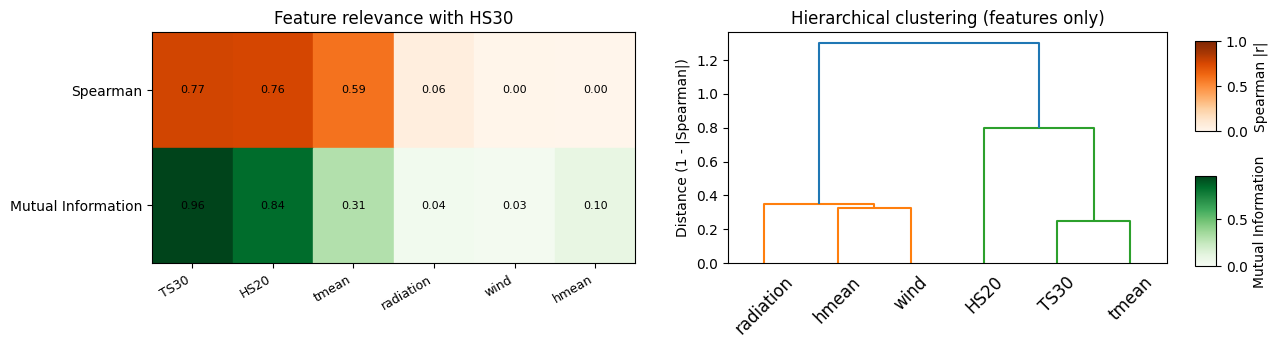

Saved to: images/drenaje30_feature_analysis.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

df = pd.read_csv("tramosDrenajeCorregido/HS30_tramos.csv")

features = ['TS30', 'tmedia', 'hmedia', 'radiacion', 'viento', 'HS20']
target = 'HS30'

df = df[features + [target]].dropna()

label_map = {
    "HS20": "HS20",
    "TS30": "TS30",
    "tmedia": "tmean",
    "hmedia": "hmean",
    "radiacion": "radiation",
    "viento": "wind"
}

spearman_target = df[features].corrwith(df[target], method='spearman')

X = df[features]
y = df[target]

mi_values = mutual_info_regression(X, y, random_state=0)
mi_target = pd.Series(mi_values, index=features)

order = spearman_target.abs().sort_values(ascending=False).index
spearman_ordered = spearman_target[order]
mi_ordered = mi_target[order]


spearman_matrix = df[features].corr(method='spearman').abs()

distance_matrix = 1 - spearman_matrix.values
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = sch.linkage(squareform(distance_matrix), method='ward')

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

fig.subplots_adjust(right=0.85)

ax1 = fig.add_subplot(gs[0, 0])

n = len(order)

ax1.set_xlim(0, n)
ax1.set_ylim(0, 2)

ax1.set_xticks(np.arange(n) + 0.5)
ax1.set_xticklabels([label_map[f] for f in order],
                    rotation=30, ha='right', fontsize=9)

ax1.set_yticks([1.5, 0.5])
ax1.set_yticklabels(['Spearman', 'Mutual Information'])

# Spearman row
for j, feat in enumerate(order):
    val = abs(spearman_ordered[feat])
    ax1.add_patch(plt.Rectangle((j, 1), 1, 1, color=plt.cm.Oranges(val)))
    ax1.text(j + 0.5, 1.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

# MI row
mi_max = mi_ordered.max()
for j, feat in enumerate(order):
    val = mi_ordered[feat]
    val_norm = val / mi_max if mi_max > 0 else 0
    ax1.add_patch(plt.Rectangle((j, 0), 1, 1, color=plt.cm.Greens(val_norm)))
    ax1.text(j + 0.5, 0.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

ax1.set_title(f"Feature relevance with {target}")


ax0 = fig.add_subplot(gs[0, 1])

sch.dendrogram(
    linkage_matrix,
    labels=[label_map[f] for f in features],
    leaf_rotation=45,
    ax=ax0
)

ax0.set_title("Hierarchical clustering (features only)")
ax0.set_ylabel("Distance (1 - |Spearman|)")

cax1 = fig.add_axes([0.87, 0.55, 0.015, 0.3])
ColorbarBase(cax1, cmap=plt.cm.Oranges,
             norm=Normalize(vmin=0, vmax=1),
             label='Spearman |r|')

cax2 = fig.add_axes([0.87, 0.1, 0.015, 0.3])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=mi_max),
             label='Mutual Information')

os.makedirs("images", exist_ok=True)

save_path = "images/drenaje30_feature_analysis.png"
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_path}")

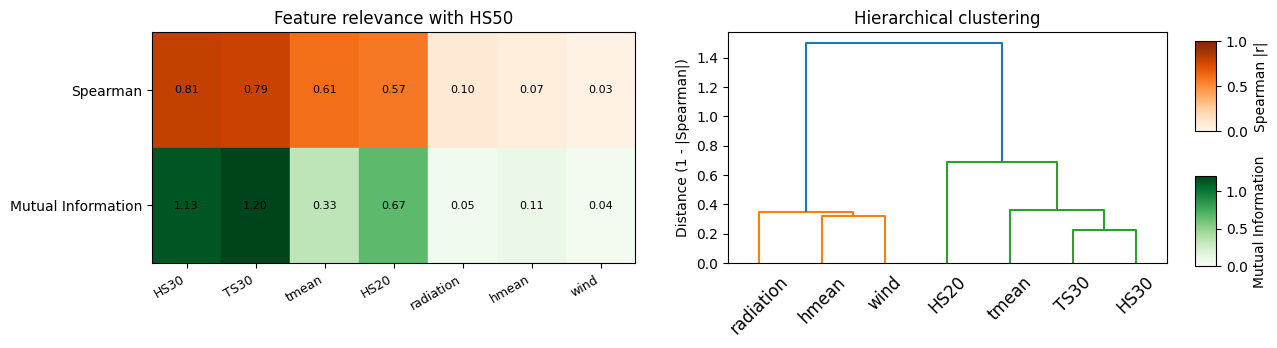

Saved to: images/drenaje50_feature_analysis.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

df = pd.read_csv("tramosDrenajeCorregido/HS50_tramos.csv")

features = ['TS30', 'tmedia', 'hmedia', 'radiacion', 'viento', 'HS20','HS30']
target = 'HS50'

df = df[features + [target]].dropna()

label_map = {
    "HS20": "HS20",
    "HS30": "HS30",
    "TS30": "TS30",
    "tmedia": "tmean",
    "hmedia": "hmean",
    "radiacion": "radiation",
    "viento": "wind"
}


spearman_target = df[features].corrwith(df[target], method='spearman')

X = df[features]
y = df[target]

mi_values = mutual_info_regression(X, y, random_state=0)
mi_target = pd.Series(mi_values, index=features)

order = spearman_target.abs().sort_values(ascending=False).index
spearman_ordered = spearman_target[order]
mi_ordered = mi_target[order]


spearman_matrix = df[features].corr(method='spearman').abs()

distance_matrix = 1 - spearman_matrix.values
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = sch.linkage(squareform(distance_matrix), method='ward')


fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

fig.subplots_adjust(right=0.85)

ax1 = fig.add_subplot(gs[0, 0])

n = len(order)

ax1.set_xlim(0, n)
ax1.set_ylim(0, 2)

ax1.set_xticks(np.arange(n) + 0.5)
ax1.set_xticklabels([label_map[f] for f in order],
                    rotation=30, ha='right', fontsize=9)

ax1.set_yticks([1.5, 0.5])
ax1.set_yticklabels(['Spearman', 'Mutual Information'])

for j, feat in enumerate(order):
    val = abs(spearman_ordered[feat])
    ax1.add_patch(plt.Rectangle((j, 1), 1, 1, color=plt.cm.Oranges(val)))
    ax1.text(j + 0.5, 1.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

mi_max = mi_ordered.max()
for j, feat in enumerate(order):
    val = mi_ordered[feat]
    val_norm = val / mi_max if mi_max > 0 else 0
    ax1.add_patch(plt.Rectangle((j, 0), 1, 1, color=plt.cm.Greens(val_norm)))
    ax1.text(j + 0.5, 0.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

ax1.set_title(f"Feature relevance with {target}")


ax0 = fig.add_subplot(gs[0, 1])

sch.dendrogram(
    linkage_matrix,
    labels=[label_map[f] for f in features],
    leaf_rotation=45,
    ax=ax0
)

ax0.set_title("Hierarchical clustering")
ax0.set_ylabel("Distance (1 - |Spearman|)")

cax1 = fig.add_axes([0.87, 0.55, 0.015, 0.3])
ColorbarBase(cax1, cmap=plt.cm.Oranges,
             norm=Normalize(vmin=0, vmax=1),
             label='Spearman |r|')

cax2 = fig.add_axes([0.87, 0.1, 0.015, 0.3])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=mi_max),
             label='Mutual Information')

os.makedirs("images", exist_ok=True)

save_path = "images/drenaje50_feature_analysis.png"
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_path}")

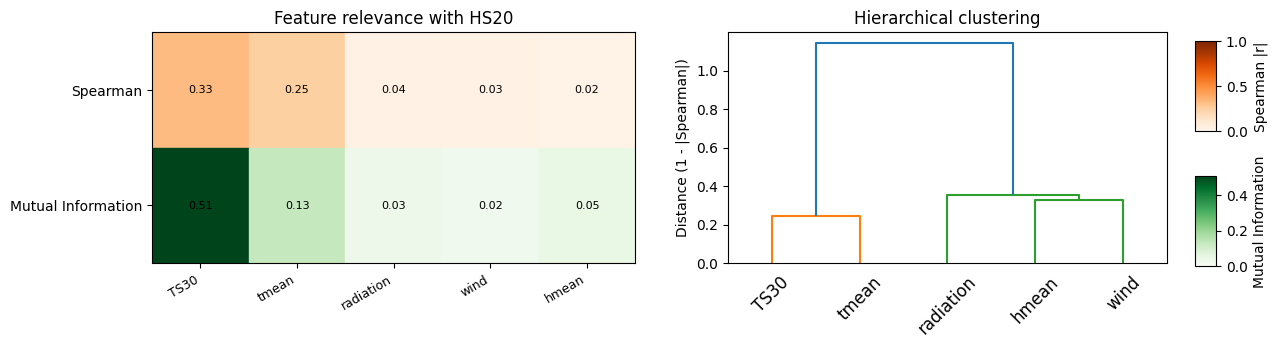

Saved to: images/drenaje20_feature_analysis.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

df = pd.read_csv("tramosDrenajeCorregido/HS20_tramos.csv")

features = ['TS30', 'tmedia', 'hmedia', 'radiacion', 'viento']
target = 'HS20'

df = df[features + [target]].dropna()

label_map = {
    "HS20": "HS20",
    "TS30": "TS30",
    "tmedia": "tmean",
    "hmedia": "hmean",
    "radiacion": "radiation",
    "viento": "wind"
}


spearman_target = df[features].corrwith(df[target], method='spearman')

X = df[features]
y = df[target]

mi_values = mutual_info_regression(X, y, random_state=0)
mi_target = pd.Series(mi_values, index=features)

order = spearman_target.abs().sort_values(ascending=False).index
spearman_ordered = spearman_target[order]
mi_ordered = mi_target[order]

spearman_matrix = df[features].corr(method='spearman').abs()

distance_matrix = 1 - spearman_matrix.values
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = sch.linkage(squareform(distance_matrix), method='ward')

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

fig.subplots_adjust(right=0.85)

ax1 = fig.add_subplot(gs[0, 0])

n = len(order)

ax1.set_xlim(0, n)
ax1.set_ylim(0, 2)

ax1.set_xticks(np.arange(n) + 0.5)
ax1.set_xticklabels([label_map[f] for f in order],
                    rotation=30, ha='right', fontsize=9)

ax1.set_yticks([1.5, 0.5])
ax1.set_yticklabels(['Spearman', 'Mutual Information'])

for j, feat in enumerate(order):
    val = abs(spearman_ordered[feat])
    ax1.add_patch(plt.Rectangle((j, 1), 1, 1, color=plt.cm.Oranges(val)))
    ax1.text(j + 0.5, 1.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

mi_max = mi_ordered.max()
for j, feat in enumerate(order):
    val = mi_ordered[feat]
    val_norm = val / mi_max if mi_max > 0 else 0
    ax1.add_patch(plt.Rectangle((j, 0), 1, 1, color=plt.cm.Greens(val_norm)))
    ax1.text(j + 0.5, 0.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

ax1.set_title(f"Feature relevance with {target}")

ax0 = fig.add_subplot(gs[0, 1])

sch.dendrogram(
    linkage_matrix,
    labels=[label_map[f] for f in features],
    leaf_rotation=45,
    ax=ax0
)

ax0.set_title("Hierarchical clustering")
ax0.set_ylabel("Distance (1 - |Spearman|)")

cax1 = fig.add_axes([0.87, 0.55, 0.015, 0.3])
ColorbarBase(cax1, cmap=plt.cm.Oranges,
             norm=Normalize(vmin=0, vmax=1),
             label='Spearman |r|')

cax2 = fig.add_axes([0.87, 0.1, 0.015, 0.3])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=mi_max),
             label='Mutual Information')

os.makedirs("images", exist_ok=True)

save_path = "images/drenaje20_feature_analysis.png"
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_path}")

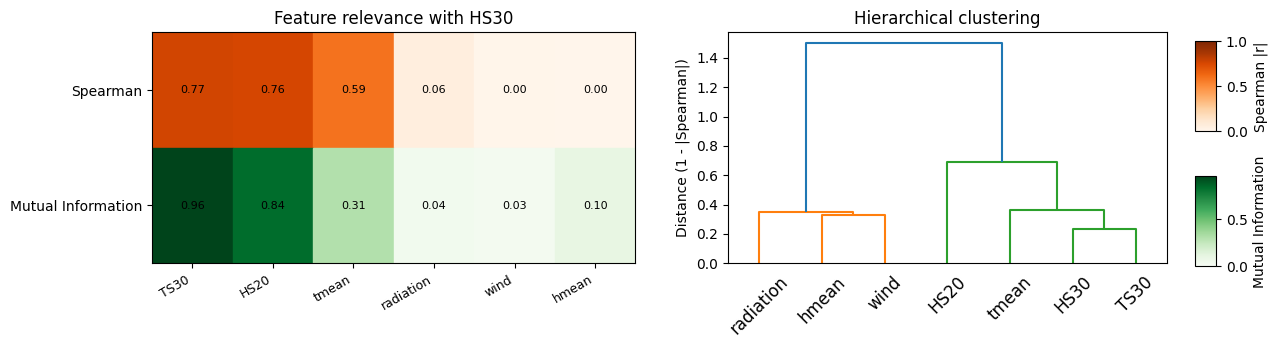

Saved to: images/drenaje30_feature_analysis.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform


df = pd.read_csv("tramosDrenajeCorregido/HS30_tramos.csv")

features = ['HS30', 'TS30', 'tmedia', 'hmedia', 'radiacion', 'viento', 'HS20']
target = 'HS30'

df = df[features].dropna()

label_map = {
    "HS30": "HS30",
    "HS20": "HS20",
    "TS30": "TS30",
    "tmedia": "tmean",
    "hmedia": "hmean",
    "radiacion": "radiation",
    "viento": "wind"
}


spearman_target = df[features].corr(method='spearman')[target].drop(target)

X = df[features]
y = df[target]

mi_values = mutual_info_regression(X, y, random_state=0)
mi_target = pd.Series(mi_values, index=features)


order = spearman_target.abs().sort_values(ascending=False).index
spearman_ordered = spearman_target[order]
mi_ordered = mi_target[order]

spearman_matrix = df[features].corr(method='spearman').abs()
distance_matrix = 1 - spearman_matrix.values
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = sch.linkage(squareform(distance_matrix), method='ward')


fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

fig.subplots_adjust(right=0.85)


ax1 = fig.add_subplot(gs[0, 0])

n = len(order)

ax1.set_xlim(0, n)
ax1.set_ylim(0, 2)

ax1.set_xticks(np.arange(n) + 0.5)
ax1.set_xticklabels([label_map[f] for f in order],
                    rotation=30, ha='right', fontsize=9)

ax1.set_yticks([1.5, 0.5])
ax1.set_yticklabels(['Spearman', 'Mutual Information'])

for j, feat in enumerate(order):
    val = abs(spearman_ordered[feat])
    ax1.add_patch(plt.Rectangle((j, 1), 1, 1, color=plt.cm.Oranges(val)))
    ax1.text(j + 0.5, 1.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

mi_max = mi_ordered.max()
for j, feat in enumerate(order):
    val = mi_ordered[feat]
    val_norm = val / mi_max if mi_max > 0 else 0
    ax1.add_patch(plt.Rectangle((j, 0), 1, 1, color=plt.cm.Greens(val_norm)))
    ax1.text(j + 0.5, 0.5, f"{val:.2f}",
             ha='center', va='center', fontsize=8)

ax1.set_title(f"Feature relevance with {target}")


ax0 = fig.add_subplot(gs[0, 1])

sch.dendrogram(
    linkage_matrix,
    labels=[label_map[f] for f in features],
    leaf_rotation=45,
    ax=ax0
)

ax0.set_title("Hierarchical clustering")
ax0.set_ylabel("Distance (1 - |Spearman|)")

cax1 = fig.add_axes([0.87, 0.55, 0.015, 0.3])
ColorbarBase(cax1, cmap=plt.cm.Oranges,
             norm=Normalize(vmin=0, vmax=1),
             label='Spearman |r|')

cax2 = fig.add_axes([0.87, 0.1, 0.015, 0.3])
ColorbarBase(cax2, cmap=plt.cm.Greens,
             norm=Normalize(vmin=0, vmax=mi_max),
             label='Mutual Information')


os.makedirs("images", exist_ok=True)

save_path = "images/drenaje30_feature_analysis.png"
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_path}")